<a href="https://colab.research.google.com/github/MustiLodhi/Aerial_Point_Segmentation_Pipeline/blob/main/Technical_Assessment_Mustafa_Lodhi_Aerial_Point_Segmentation_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.7 MB/s eta 0:00:00


In [10]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
from google.colab import userdata

hf_token = userdata.get('HF_TOKEN')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class RemoteSensingPointDataset(Dataset):
    def __init__(self, num_samples=100, img_size=256, num_classes=4, points_per_class=20):
        self.num_samples = num_samples
        self.img_size = img_size
        self.num_classes = num_classes
        self.points_per_class = points_per_class

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        image = torch.rand(3, self.img_size, self.img_size)
        dense_mask = torch.randint(0, self.num_classes, (self.img_size, self.img_size))
        point_mask = torch.full_like(dense_mask, 255)

        for cls in range(self.num_classes):
            coords = torch.nonzero(dense_mask == cls)
            if len(coords) > 0:
                n_samples = min(self.points_per_class, len(coords))
                indices = torch.randperm(len(coords))[:n_samples]
                sampled_coords = coords[indices]
                point_mask[sampled_coords[:, 0], sampled_coords[:, 1]] = cls

        return image, point_mask, dense_mask

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=4
).to(device)

criterion = smp.losses.FocalLoss(
    mode="multiclass",
    alpha=0.25,
    gamma=2.0,
    ignore_index=255
)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)

dataset = RemoteSensingPointDataset()
dataloader = DataLoader(dataset, batch_size=8, shuffle=True)

model.train()
for epoch in range(5):
    epoch_loss = 0.0

    for images, point_masks, _ in dataloader:
        images = images.to(device)
        point_masks = point_masks.to(device)

        optimizer.zero_grad()
        predictions = model(images)
        loss = criterion(predictions, point_masks)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    print(f"Epoch {epoch + 1}/5 | Average Partial Loss: {epoch_loss / len(dataloader):.4f}")

Epoch 1/5 | Average Partial Loss: 0.4055
Epoch 2/5 | Average Partial Loss: 0.2410
Epoch 3/5 | Average Partial Loss: 0.2263
Epoch 4/5 | Average Partial Loss: 0.2235
Epoch 5/5 | Average Partial Loss: 0.2218


In [6]:
!pip install segmentation-models-pytorch datasets matplotlib


In [11]:
import os
import torch
import numpy as np
from torch.utils.data import Dataset
from datasets import load_dataset
from google.colab import userdata

hf_token = userdata.get('HF_TOKEN')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

hf_data_full = load_dataset("sjyhne/mapai_dataset", token=hf_token)
train_split = hf_data_full['train'].select(range(100))
test_sample = hf_data_full['validation'].select(range(3))

class RealAerialPointDataset(Dataset):
    def __init__(self, hf_dataset, points_per_class=20):
        self.data = hf_dataset
        self.points_per_class = points_per_class

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]

        img_array = np.array(item['image']).astype(np.float32) / 255.0
        image = torch.from_numpy(img_array).permute(2, 0, 1)

        dense_mask = torch.from_numpy(np.array(item['mask'])).long()
        point_mask = torch.full_like(dense_mask, 255)

        for cls in range(2):
            coords = torch.nonzero(dense_mask == cls)
            if len(coords) > 0:
                n_samples = min(self.points_per_class, len(coords))
                indices = torch.randperm(len(coords))[:n_samples]
                sampled_coords = coords[indices]
                point_mask[sampled_coords[:, 0], sampled_coords[:, 1]] = cls

        return image, point_mask, dense_mask

Resolving data files:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 1/5 | Loss: 0.1826
Epoch 2/5 | Loss: 0.1127
Epoch 3/5 | Loss: 0.0843
Epoch 4/5 | Loss: 0.0733
Epoch 5/5 | Loss: 0.0607


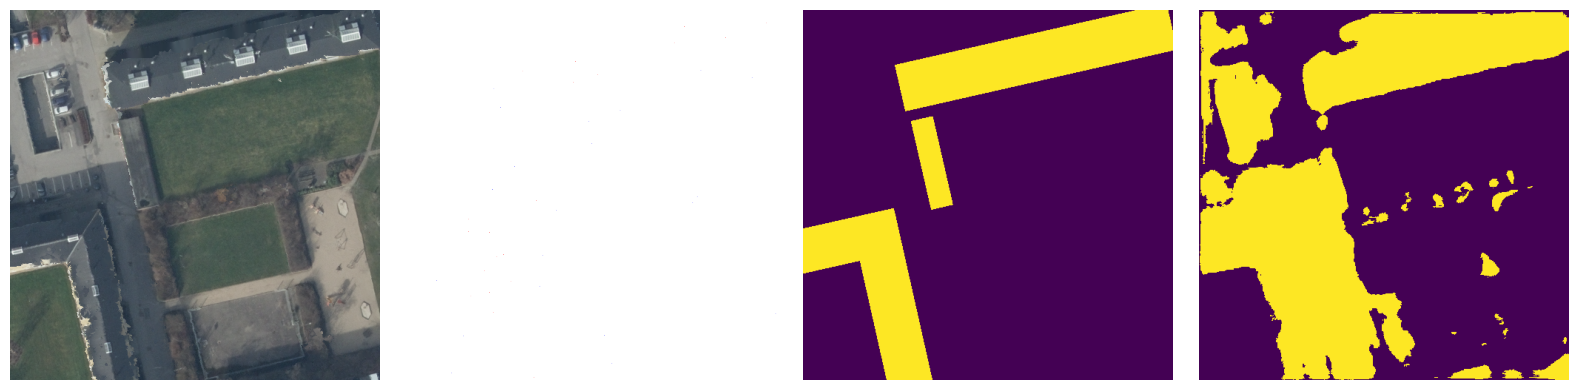

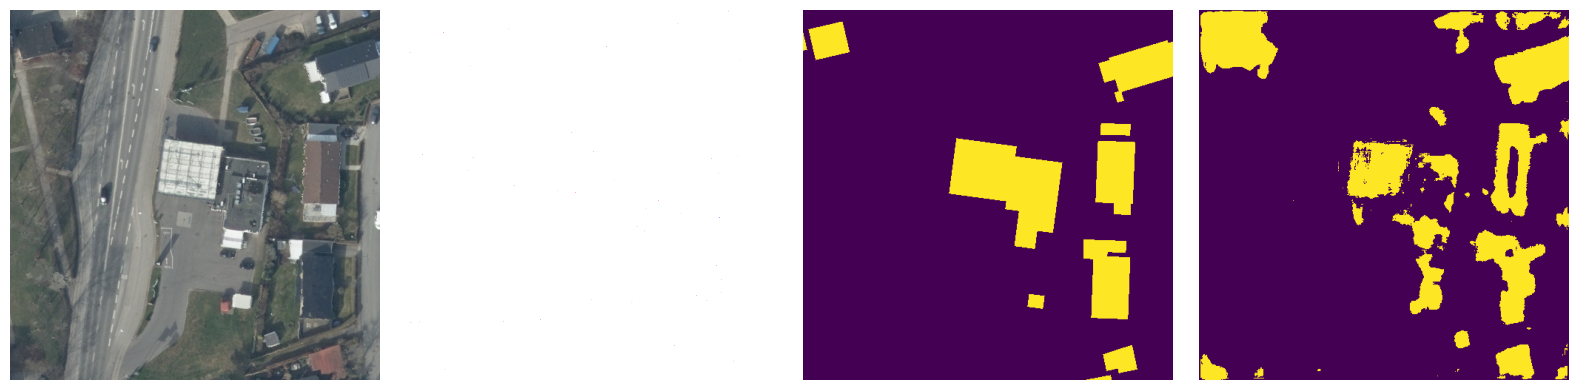

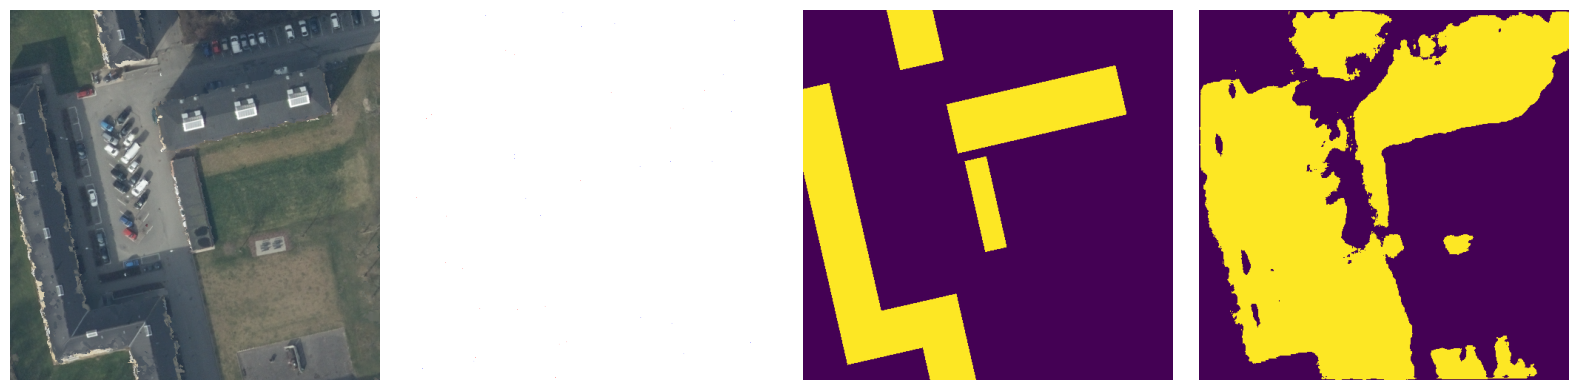

In [12]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import segmentation_models_pytorch as smp

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = smp.Unet(encoder_name="resnet34", encoder_weights="imagenet", classes=2).to(device)
criterion = smp.losses.FocalLoss(mode="multiclass", alpha=0.25, gamma=2.0, ignore_index=255)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)

dataset = RealAerialPointDataset(train_split, points_per_class=20)
dataloader = DataLoader(dataset, batch_size=8, shuffle=True)

model.train()
for epoch in range(5):
    epoch_loss = 0.0
    for images, point_masks, _ in dataloader:
        images, point_masks = images.to(device), point_masks.to(device)
        optimizer.zero_grad()
        predictions = model(images)
        loss = criterion(predictions, point_masks)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    print(f"Epoch {epoch + 1}/5 | Loss: {epoch_loss / len(dataloader):.4f}")

model.eval()
viz_dataset = RealAerialPointDataset(test_sample, points_per_class=20)
viz_loader = DataLoader(viz_dataset, batch_size=1)

with torch.no_grad():
    for i, (image, point_mask, dense_mask) in enumerate(viz_loader):
        if i >= 3: break

        image_gpu = image.to(device)
        output = model(image_gpu)
        prediction = torch.argmax(output.squeeze(), dim=0).cpu().numpy()

        raw_img = image.squeeze().permute(1, 2, 0).numpy()
        p_mask = point_mask.squeeze().numpy()
        d_mask = dense_mask.squeeze().numpy()

        plt.figure(figsize=(16, 4))

        plt.subplot(1, 4, 1)
        plt.imshow(raw_img)
        plt.axis('off')

        plt.subplot(1, 4, 2)
        points_viz = p_mask.copy()
        mask = np.ones((p_mask.shape[0], p_mask.shape[1], 4), dtype=np.float32)
        mask[points_viz == 255, 3] = 0.0
        mask[points_viz == 1, 0:3] = [1, 0, 0]
        mask[points_viz == 0, 0:3] = [0, 0, 1]
        plt.imshow(mask)
        plt.axis('off')

        plt.subplot(1, 4, 3)
        plt.imshow(d_mask, cmap='viridis')
        plt.axis('off')

        plt.subplot(1, 4, 4)
        plt.imshow(prediction, cmap='viridis')
        plt.axis('off')

        plt.tight_layout()
        plt.show()

Epoch 1/5 | Loss: 0.1628
Epoch 2/5 | Loss: 0.0740
Epoch 3/5 | Loss: 0.0548
Epoch 4/5 | Loss: 0.0456
Epoch 5/5 | Loss: 0.0402


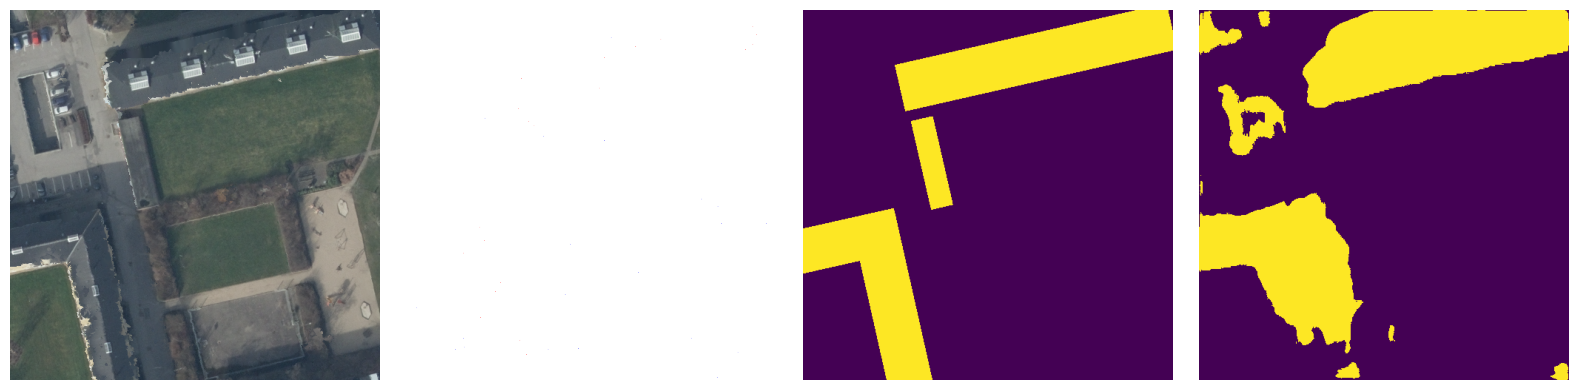

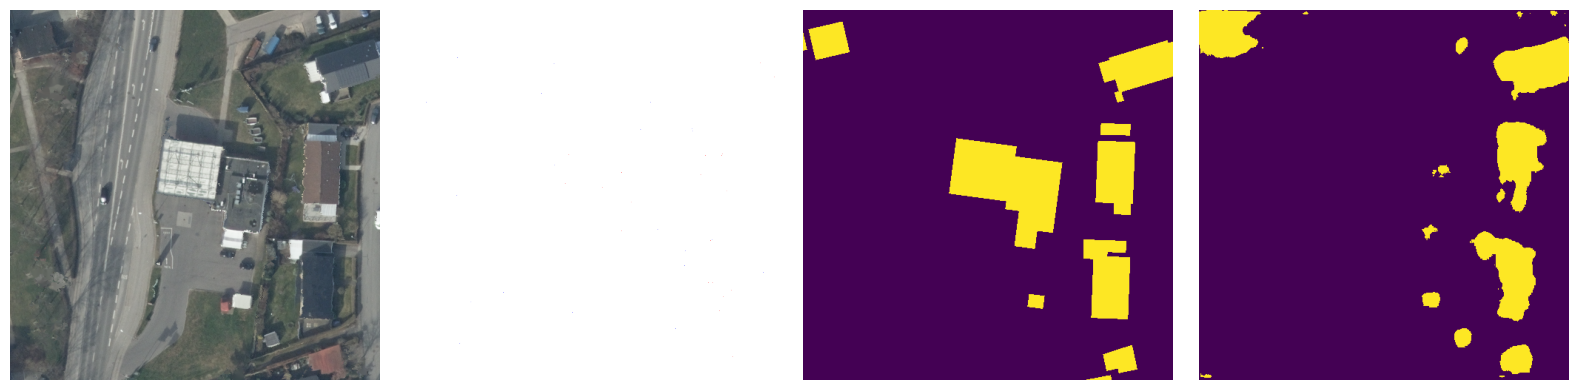

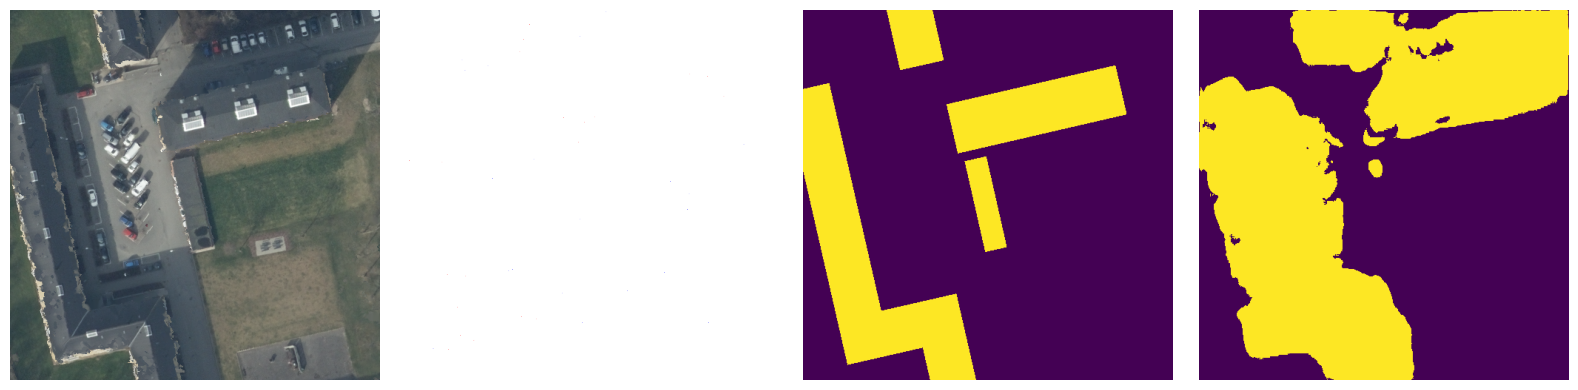

In [13]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import segmentation_models_pytorch as smp

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = smp.Unet(encoder_name="resnet34", encoder_weights="imagenet", classes=2).to(device)
criterion = smp.losses.FocalLoss(mode="multiclass", alpha=0.25, gamma=2.0, ignore_index=255)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)

dataset = RealAerialPointDataset(train_split, points_per_class=100)
dataloader = DataLoader(dataset, batch_size=8, shuffle=True)

model.train()
for epoch in range(5):
    epoch_loss = 0.0
    for images, point_masks, _ in dataloader:
        images, point_masks = images.to(device), point_masks.to(device)
        optimizer.zero_grad()
        predictions = model(images)
        loss = criterion(predictions, point_masks)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    print(f"Epoch {epoch + 1}/5 | Loss: {epoch_loss / len(dataloader):.4f}")

model.eval()
viz_dataset = RealAerialPointDataset(test_sample, points_per_class=20)
viz_loader = DataLoader(viz_dataset, batch_size=1)

with torch.no_grad():
    for i, (image, point_mask, dense_mask) in enumerate(viz_loader):
        if i >= 3: break

        image_gpu = image.to(device)
        output = model(image_gpu)
        prediction = torch.argmax(output.squeeze(), dim=0).cpu().numpy()

        raw_img = image.squeeze().permute(1, 2, 0).numpy()
        p_mask = point_mask.squeeze().numpy()
        d_mask = dense_mask.squeeze().numpy()

        plt.figure(figsize=(16, 4))

        plt.subplot(1, 4, 1)
        plt.imshow(raw_img)
        plt.axis('off')

        plt.subplot(1, 4, 2)
        points_viz = p_mask.copy()
        mask = np.ones((p_mask.shape[0], p_mask.shape[1], 4), dtype=np.float32)
        mask[points_viz == 255, 3] = 0.0
        mask[points_viz == 1, 0:3] = [1, 0, 0]
        mask[points_viz == 0, 0:3] = [0, 0, 1]
        plt.imshow(mask)
        plt.axis('off')

        plt.subplot(1, 4, 3)
        plt.imshow(d_mask, cmap='viridis')
        plt.axis('off')

        plt.subplot(1, 4, 4)
        plt.imshow(prediction, cmap='viridis')
        plt.axis('off')

        plt.tight_layout()
        plt.show()